<a href="https://colab.research.google.com/github/mromanenko095/sympy-solutions/blob/main/10_curved_mirrors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Криволинейные зеркала

Выполнил: Романенко Михаил Юрьевич, 409460

Требуется найти кривую, после отражения от которой параллельный пучок сходится (фокусируется) в одной общей точке - фокусе. Пусть исходный пучок состоит из вертикальных лучей. Введем систему координат, ось $Oy$ направим против направления лучей (лучи падают на искомую кривую сверху вниз). Считаем, что точка фокуса находится в начале координат - после отражения от кривой все лучи должны пройти через точку $O$.

Пусть искомая кривая задана функцией $y(x)$. Рассмотрим траекторию луча $MAO$ (отражение происходит в точке $A(x, y)$). По закону отражения угол падения $\angle{MAN}$ равен углу отражения $\angle{OAB}$: $$\angle{OAB} = \angle{MAN} = \angle{BAC}$$.

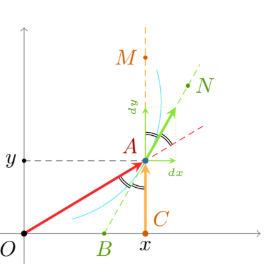

Воспользуемся векторным способом. Угол между векторами $OA$ и $BA$ равен углу между векторами $BA$ и $CA$. Координаты вектора $OA$ находятся элементарно: $OA = (x, y)$. Заметим, что прямая $BA$ является касательной к y(x), поэтому вектор $BA$ должен быть сонаправлен вектору $δ = (dx, dy)$. Следовательно, при сравнении углов между векторами мы можем заменить вектор $BA$ на вектор $\delta$. А вместо вектора $CA$ возьмем сонаправленный с ним единичный вектор $e = (0, 1)$. Применим формулу для косинуса угла между векторами:

1. Подключаем необходимые библиотеки.

In [ ]:
from sympy import *
from IPython.display import display
import numpy as np

2. Задаем переменные и функцию.

In [ ]:
X, Y, x = symbols("X Y x")  # создаем символьные переменные, так как sympy работает только с символами
y = Function("y")(x)  # просто задаем функцию y(x)

3. Вычисляем производную $k = y'(x)$, задаем коэффициенты $A$ и $B$.

In [ ]:
k = diff(y, x)  # производная y по x
A = (k ** 2 - 1) / (2 * k)
B = simplify(y - x * A)  # упрощает выражение
display(A, B)

(Derivative(y(x), x)**2 - 1)/(2*Derivative(y(x), x))

-x*Derivative(y(x), x)/2 + x/(2*Derivative(y(x), x)) + y(x)

4. Записываем уравнение семейства отраженных лучей

In [ ]:
fam = Eq(Y, A * X + B)  # создает уравнение вида Y = AX + B
display(fam)

Eq(Y, X*(Derivative(y(x), x)**2 - 1)/(2*Derivative(y(x), x)) - x*Derivative(y(x), x)/2 + x/(2*Derivative(y(x), x)) + y(x))

5. Построим семейство лучей, отраженных от нижней единичной полуокружности

In [ ]:
f1 = -sqrt(1 - x ** 2)  # уравнение нижней половины полуокружности
fam1 = simplify(fam.subs(y, f1).doit())
'''
fam - уравнение семейства отраженных лучей
fam.subs(y, f1) заменяет в выражении fam все вхождения y на конкретное выражение f1
.doit() явно вычисляет "отложенные на потом" операции, так как в sympy многие операция не вычисляются сразу а остаются в виде Derivative(...)
simplify - упрощение выражения
'''
# fam 1 - уравнение конкретного семейства прямых
display(fam1)

Eq(Y, (2*X*x**2 - X - x)/(2*x*sqrt(1 - x**2)))

6. Строим график полученного семейства ```fam1``` и поверх него исходную полуокружность. Внутри окружности видна кривая, образованная сгущением прямых линий - каустика.

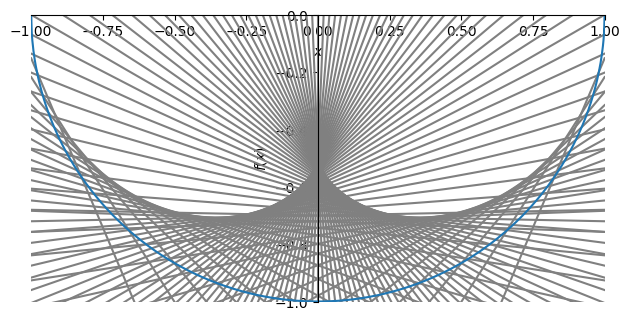

In [ ]:
p1 = plot(xlim=(-1, 1), ylim=(-1, 0), aspect_ratio=(1, 1), show=False)  # постепенно накапливаем линии на графике, покажем только в конце. aspect_ratio - одинаковый масштаб по осям
for x0 in np.arange(-0.98, 1, 0.02):  # каждый шаг рисует один луч, падающий в x0
  l = fam1.rhs.subs(x, x0)  # fam1 - уравнение вида Y = выражение(X, x); .rhs - берем правую часть (Y), l - итоговый луч
  p=plot(l, (X, -1, 1), line_color='gray', show=False)
  p1.extend(p)  # добавляем луч в общий контейнер
p1.extend(plot(f1, (x, -1, 1), show=False))  # добавляем кривую
p1.show()

7. Вычислим параметрическое уравнение огибающей семейства ```fam1```.

In [ ]:
A1 = A.subs(y, f1).doit()
B1 = B.subs(y, f1).doit()
XC = simplify(- diff(B1, x) / diff(A1, x))
YC = simplify(A1 * XC + B1)
display(XC, YC)

x**3

(2*x**4 - x**2 - 1)/(2*sqrt(1 - x**2))

8. Добавляем каустику $(XC, YC)$ на график

<lambdifygenerated-203>:2: RuntimeWarning: invalid value encountered in scalar divide
  return (1/2)*(2*x**4 - x**2 - 1)/sqrt(1 - x**2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2480: RuntimeWarning: invalid value encountered in wrapper_func (vectorized)
  outputs = ufunc(*inputs)


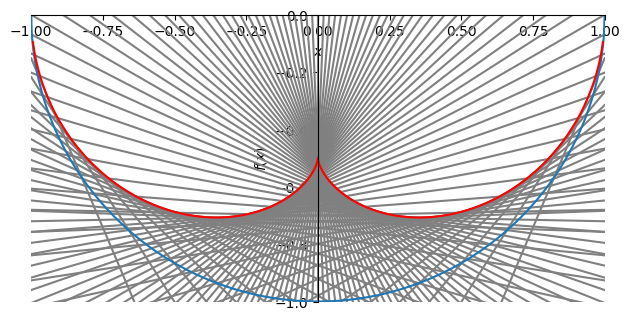

In [ ]:
p2 = plot(xlim=(-1, 1), ylim=(-1, 0), aspect_ratio=(1, 1), show=False)  # контейнер для графиков
p = plot_parametric((XC, YC), (x, -1, 1), line_color='red', show=False)  # построение параметрического графика каустики. x меняется от -1 до 1.
p2.extend(p1)  # добавляем лучи и окружность в контейнер
p2.extend(p)  # добавляем акустику в контейнер
p2.show()

9. Определяем символы для дифференциалов и строим 3 вектора с помощью кортежей SymPy.

In [ ]:
dx, dy = symbols('dx dy')
OA = Tuple(x, y)
delta = Tuple(dx, dy)
e = Tuple(0, 1)
display(OA, delta, e)

(x, y(x))

(dx, dy)

(0, 1)

10. Определяем функцию для скалярного произведения двух двумерных векторов и тестируем ее.

In [ ]:
def dot(u, v):
  return u[0] * v[0] + u[1] * v[1]

display(dot(OA, delta))

dx*x + dy*y(x)

11. Определяем функцию для вычисления длины заданного вектора, тестируем ее.

In [ ]:
def length(u):
  return sqrt(dot(u, u))

display(length(OA))

sqrt(x**2 + y(x)**2)

12. Составляем искомое дифференциальное уравнение.

In [ ]:
ode = Eq(dot(OA, delta) / length(OA),
         dot(e, delta) / length(e))

display(ode)

Eq((dx*x + dy*y(x))/sqrt(x**2 + y(x)**2), dy)

13. Перейдем от уравнения в дифференциалах к уравнению с производной.

In [ ]:
ode1 = ode.subs({dx: 1, dy: diff(y, x)})

display(ode1)

Eq((x + y(x)*Derivative(y(x), x))/sqrt(x**2 + y(x)**2), Derivative(y(x), x))

14. Проверим тип уравнения.

In [ ]:
classify_ode(ode1, y)

('factorable',
 '1st_exact',
 '1st_homogeneous_coeff_best',
 '1st_homogeneous_coeff_subs_indep_div_dep',
 '1st_homogeneous_coeff_subs_dep_div_indep',
 '1st_power_series',
 'lie_group',
 '1st_exact_Integral',
 '1st_homogeneous_coeff_subs_indep_div_dep_Integral',
 '1st_homogeneous_coeff_subs_dep_div_indep_Integral')

15. Судя по второй строке вывода, тип уравнения - уравнение в полных дифференциалах.

Решим уравнение ```ode1``` как уравнение в полных дифференциалах, используя подсказку ```1st_exact```.

In [ ]:
dsol = dsolve(ode1, y, hint='1st_exact')

display(dsol)

Eq(y(x), -C1/2 + x**2/(2*C1))

16. Найденное решение оказалось квадратичной функцией. Следовательно, искомые кривые - параболы. Построим семейство таких парабол. Так как все они имеют общую точку фокуса, данное семейство называется семейством конфокальных парабол.

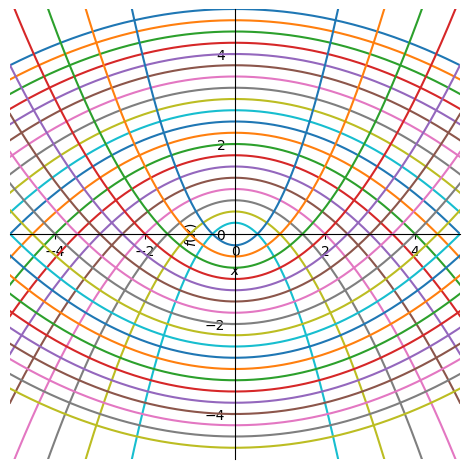

In [ ]:
C1 = symbols("C1")
p3 = plot(xlim=(-5, 5), ylim=(-5, 5),
          aspect_ratio=(1, 1),
          show=False)

for c in np.arange(-10, 10, 0.5):
    if abs(c) < 1e-9:  # пропускаем c = 0
        continue
    y_expr = dsol.rhs.subs(C1, c)
    p = plot(y_expr, (x, -5, 5), show=False)
    p3.extend(p)

p3.show()

17. Выберем одну из найденных парабол (например $C_1 = 1$) и построим семейство отраженных от нее лучей, чтобы проверить, что эти лучи проходят через начало координат. Определим уравнение данной параболы и сохраним его в ```f2```.

In [ ]:
f2 = dsol.rhs.subs(C1, 1)

display(f2)

x**2/2 - 1/2

18. Подставим эту формулу в общее уравнение ```fam``` семейства отраженных лучей.

In [ ]:
fam2 = fam.subs(y, f2).doit()

display(fam2)

Eq(Y, X*(x**2 - 1)/(2*x))

19. Построим на одном графике параболу ```f2``` и порожденное ею семейство прямых ```fam2```.

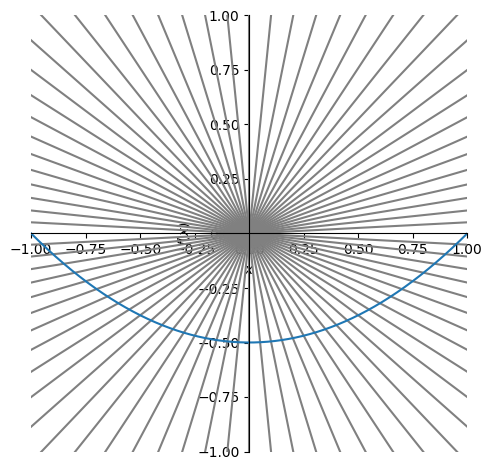

In [ ]:
p4 = plot(xlim=(-1, 1), ylim=(-1, 1), aspect_ratio=(1, 1), show=False)
for x0 in np.arange(-0.95, 1, 0.05):
  l = fam2.rhs.subs(x, x0)
  p = plot(l, (X, -1, 1), line_color='gray', show=False)
  p4.extend(p)
p4.extend(plot(f2, (x, -1, 1), show=False))
p4.show()

Результат построения наглядно показывает фокусирование отраженных лучей в начале координат.

# УПРАЖНЕНИЕ 1. ВАРИАНТ 1

$2xydx + (x^2 - y^2)dy = 0$

In [ ]:
from sympy import *

x, y = symbols('x y')
y_func = Function('y')(x)

ode = Eq(2 * x * y_func + (x**2 - y_func**2) * diff(y_func, x), 0)

display(classify_ode(ode, y_func))  # выводим, что ур-ие в полных дифференциалах
print()

sol_exact = dsolve(ode, y_func, hint='1st_exact', simplify=False)

display(sol_exact)


('factorable',
 '1st_exact',
 '1st_homogeneous_coeff_best',
 '1st_homogeneous_coeff_subs_indep_div_dep',
 '1st_homogeneous_coeff_subs_dep_div_indep',
 '1st_power_series',
 'lie_group',
 '1st_exact_Integral',
 '1st_homogeneous_coeff_subs_indep_div_dep_Integral',
 '1st_homogeneous_coeff_subs_dep_div_indep_Integral')

Eq(x**2*y(x) - y(x)**3/3, C1)

In [ ]:
# Решение с другой подсказкой
'''
sol_homog = dsolve(ode, y_func, hint='1st_homogeneous_coeff_best')
display(sol_homog)
'''

"\nsol_homog = dsolve(ode, y_func, hint='1st_homogeneous_coeff_best')\ndisplay(sol_homog)\n"

# УПРАЖНЕНИЕ 3. ВАРИАНТ 1

Постройте каустику отражения, порожденную заданной кривой $y(x) = x^3$, для случая параллельного пучка лучей, падающих на эту кривую сверху вниз.

(Derivative(y(x), x)**2 - 1)/(2*Derivative(y(x), x))

-x*Derivative(y(x), x)/2 + x/(2*Derivative(y(x), x)) + y(x)

Eq(Y, X*(Derivative(y(x), x)**2 - 1)/(2*Derivative(y(x), x)) - x*Derivative(y(x), x)/2 + x/(2*Derivative(y(x), x)) + y(x))

Eq(Y, (X*(9*x**4 - 1) - 3*x**5 + x)/(6*x**2))

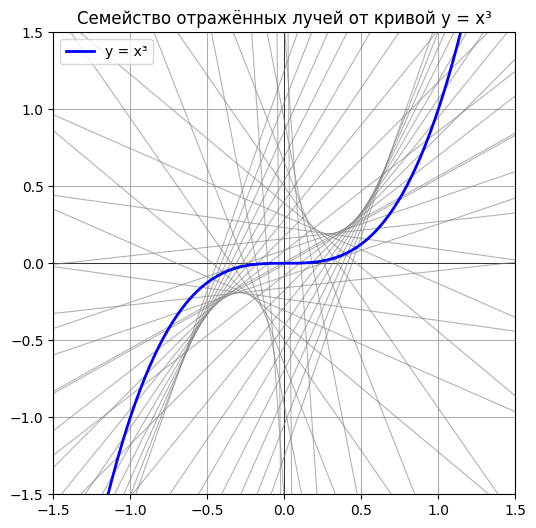

x/2

(3*x**4 + 1)/(12*x)

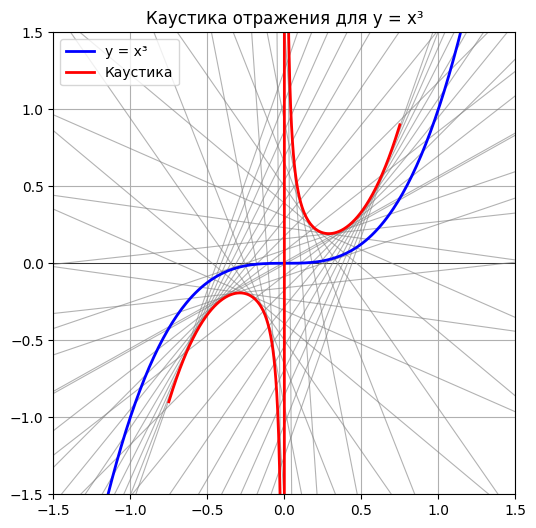

In [ ]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

X, Y, x = symbols("X Y x")
y = Function("y")(x)

k = diff(y, x)
A = (k**2 - 1) / (2*k)  # тангенс угла отражённого луча
B = simplify(y - x*A)  # свободный член

fam = Eq(Y, A*X + B)  # уравнение семейства прямых
display(A, B, fam)

f1 = x**3
fam1 = simplify(fam.subs(y, f1).doit())
display(fam1)

# Преобразуем символьное выражение в числовую функцию
l_expr = fam1.rhs   # правая часть уравнения Y = ...
L_func = lambdify((X, x), l_expr, 'numpy')

# Параметры графика
x_vals = np.linspace(-1.5, 1.5, 400)
X_plot = np.linspace(-1.5, 1.5, 400)

plt.figure(figsize=(6,6))
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.gca().set_aspect('equal')

# Рисуем лучи для разных x0 (точек падения)
for x0 in np.linspace(-1.4, 1.4, 40):
    # Вычисляем Y для каждого X
    Y_vals = L_func(X_plot, x0)
    plt.plot(X_plot, Y_vals, 'gray', alpha=0.6, lw=0.8)

# Рисуем саму кривую y = x^3
x_curve = np.linspace(-1.5, 1.5, 300)
y_curve = x_curve**3
plt.plot(x_curve, y_curve, 'b-', lw=2, label='y = x³')

plt.title('Семейство отражённых лучей от кривой y = x³')
plt.legend()
plt.grid(True)
plt.show()

A1 = A.subs(y, f1).doit()
B1 = B.subs(y, f1).doit()

XC = simplify(-diff(B1, x) / diff(A1, x))
YC = simplify(A1 * XC + B1)

display(XC, YC)

# Параметрическая кривая каустики: x = t/2, y = (3t^4+1)/(12t)
t = np.linspace(-1.5, 1.5, 500)
t = t[t != 0]   # исключаем ноль, где знаменатель нулевой
Xc_vals = t/2
Yc_vals = (3*t**4 + 1)/(12*t)

# Повторяем построение лучей (как выше) и добавляем каустику
plt.figure(figsize=(6,6))
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.gca().set_aspect('equal')

# Лучи
for x0 in np.linspace(-1.4, 1.4, 40):
    Y_vals = L_func(X_plot, x0)
    plt.plot(X_plot, Y_vals, 'gray', alpha=0.6, lw=0.8)

# Кривая y = x^3
plt.plot(x_curve, y_curve, 'b-', lw=2, label='y = x³')

# Каустика
plt.plot(Xc_vals, Yc_vals, 'r-', lw=2, label='Каустика')

plt.legend()
plt.grid(True)
plt.title('Каустика отражения для y = x³')
plt.show()

# УПРАЖНЕНИЕ 11. ВАРИАНТ 2

Выведите уравнение каустики для общего случая, когда лучи, исходящие из начала координат, падают снизу на заданную кривую $y(x) = (x - 1)^2 (x + 1)$

In [ ]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

x, X, Y = symbols('x X Y')
y = Function('y')(x)

k = diff(y, x)

A = (2*k*x - y*(1 - k**2)) / (x*(1 - k**2) + 2*k*y)
B = y - A*x

y_expr = x**3 - x**2 - x + 1
k_expr = diff(y_expr, x)  # 3*x**2 - 2*x - 1

A1 = simplify(A.subs({y: y_expr, k: k_expr}))
B1 = simplify(B.subs({y: y_expr, k: k_expr}))

print("A(x) =", A1)
print("B(x) =", B1)

# Производные
dA = diff(A1, x)
dB = diff(B1, x)

# Каустика
Xc = simplify(-dB / dA)
Yc = simplify(A1 * Xc + B1)

print("Xc =", Xc)
print("Yc =", Yc)

A(x) = x*(-9*x**6 + 21*x**5 - x**4 - 27*x**3 + 8*x**2 + 10*x - 2)/(3*x**5 - 2*x**4 + 2*x**3 - 8*x**2 + 2*x + 2)
B(x) = 2*(6*x**8 - 13*x**7 + x**6 + 11*x**5 - x**4 - 5*x**2 + 1)/(3*x**5 - 2*x**4 + 2*x**3 - 8*x**2 + 2*x + 2)
Xc = 2*(6*x**8 - 6*x**7 + 9*x**6 - 36*x**5 + 21*x**4 + 12*x**3 - 9*x**2 - 1)/(6*x**7 - 5*x**6 + 12*x**5 - 51*x**4 + 28*x**3 + 24*x**2 - 24*x + 2)
Yc = 2*(-6*x**10 + 20*x**9 - 6*x**8 - 48*x**7 + 42*x**6 + 36*x**5 - 57*x**4 + 12*x**3 + 18*x**2 - 12*x + 1)/(6*x**7 - 5*x**6 + 12*x**5 - 51*x**4 + 28*x**3 + 24*x**2 - 24*x + 2)


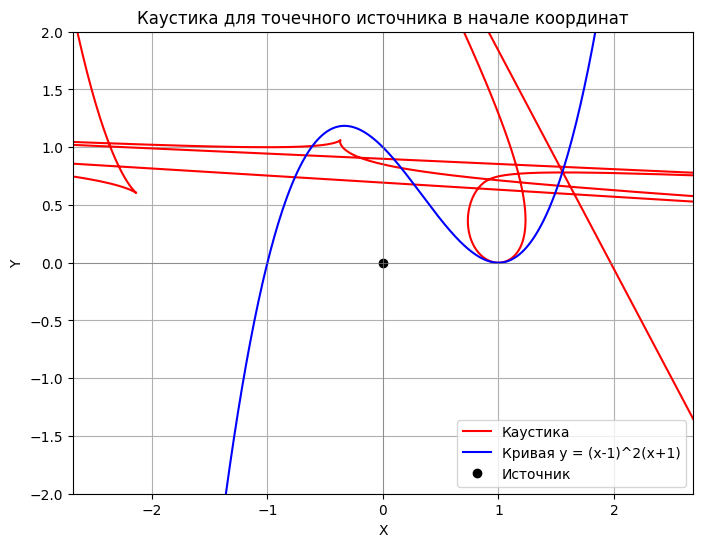

In [ ]:
# Преобразуем в числовые функции
Xc_func = lambdify(x, Xc, 'numpy')
Yc_func = lambdify(x, Yc, 'numpy')

# Диапазон x, где знаменатель не обращается в ноль (3x^2-2x-1=0 => x=1, x=-1/3)
x_vals = np.linspace(-2, 2, 500)
# Исключаем особые точки
x_vals = x_vals[~np.isclose(x_vals, -1/3)]
x_vals = x_vals[~np.isclose(x_vals, 1)]

X_vals = Xc_func(x_vals)
Y_vals = Yc_func(x_vals)

# Сама кривая y = (x-1)^2(x+1)
x_curve = np.linspace(-1.5, 2, 300)
y_curve = (x_curve-1)**2 * (x_curve+1)

plt.figure(figsize=(8,6))
plt.plot(X_vals, Y_vals, 'r-', label='Каустика')
plt.plot(x_curve, y_curve, 'b-', label='Кривая y = (x-1)^2(x+1)')
plt.plot(0,0,'ko', label='Источник')
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Каустика для точечного источника в начале координат')
plt.grid(True)
plt.axis('equal')
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.show()

### Общее неявное уравнение семейства отраженных лучей $F(X, Y, t) = 0$:

        ⎛                              2       ⎞              ⎛  ⎛          2  ↪
        ⎜    d               │d       │        ⎟              ⎜  ⎜│d       │   ↪
(X - t)⋅⎜2⋅t⋅──(y(t)) + y(t)⋅│──(y(t))│  - y(t)⎟ - (Y - y(t))⋅⎜t⋅⎜│──(y(t))│   ↪
        ⎝    dt              │dt      │        ⎠              ⎝  ⎝│dt      │   ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                            2                  ↪
                                                  │d       │                   ↪
                                                  │──(y(t))│  + 1              ↪
                                                  │dt      │                   ↪

↪    ⎞                                 ⎞    
↪    ⎟     ⎛  d              ⎞ d       ⎟    
↪ + 1⎟ - 2⋅⎜t⋅──(y(t)) - y(t)⎟⋅──(y(t))⎟    
↪    ⎠     ⎝  dt             ⎠ dt      ⎠    
↪ ────────────────────────────────────── = 0
↪                                           


### Параметрические уравнения каустики $X(t)$ и $Y(t)$ для заданной кривой:

        8       7       6       5       4       3       2    
    12⋅t  - 12⋅t  + 18⋅t  - 72⋅t  + 42⋅t  + 24⋅t  - 18⋅t  - 2
X = ─────────────────────────────────────────────────────────
        7      6       5       4       3       2             
     6⋅t  - 5⋅t  + 12⋅t  - 51⋅t  + 28⋅t  + 24⋅t  - 24⋅t + 2  

          10       9       8       7       6       5        4       3       2  ↪
    - 12⋅t   + 40⋅t  - 12⋅t  - 96⋅t  + 84⋅t  + 72⋅t  - 114⋅t  + 24⋅t  + 36⋅t   ↪
Y = ────────────────────────────────────────────────────────────────────────── ↪
                      7      6       5       4       3       2                 ↪
                   6⋅t  - 5⋅t  + 12⋅t  - 51⋅t  + 28⋅t  + 24⋅t  - 24⋅t + 2      ↪

↪           
↪ - 24⋅t + 2
↪ ──────────
↪           
↪           

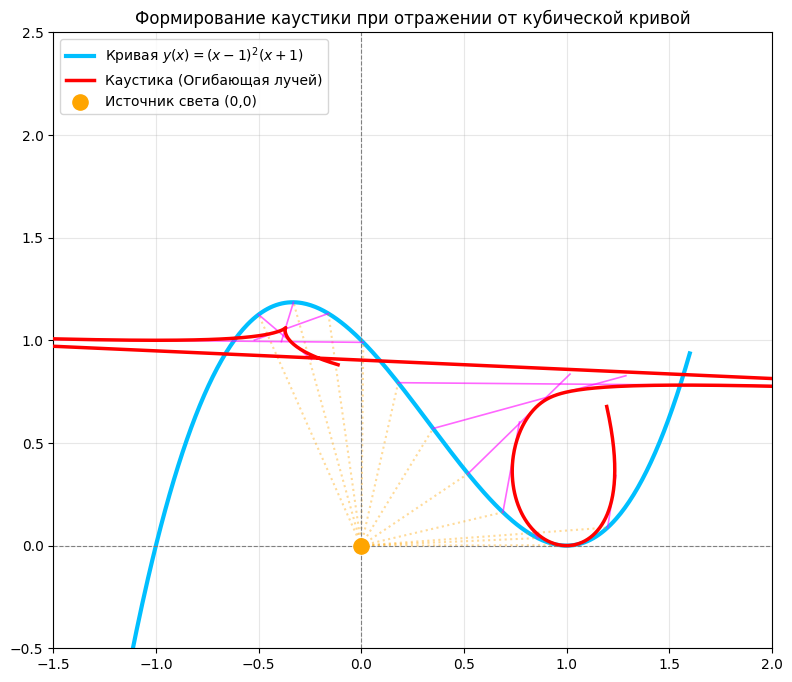

In [ ]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Настройка красивого вывода формул
init_printing(use_latex='mathjax')

# =============================================================================
# ЧАСТЬ 1: ВЫВОД ОБЩЕЙ ФОРМУЛЫ И ВЫЧИСЛЕНИЕ ДЛЯ ЗАДАННОЙ КРИВОЙ
# =============================================================================

# Определение символов
# t - координата x точки отражения на кривой (параметр семейства лучей)
# X, Y - текущие координаты на плоскости, где ищется каустика
t = Symbol('t', real=True)
X, Y = symbols('X Y', real=True)

# Задаем абстрактные функции для кривой в точке t
y = Function('y')(t)
dy = y.diff(t)

# 1. Вектор падающего луча из начала координат (0,0) в точку (t, y(t))
r_in = Matrix([t, y])

# 2. Вектор нормали к кривой в точке (t, y(t)). Так как касательная равна (1, y'), нормаль равна (-y', 1)
n = Matrix([-dy, 1])

# 3. Направляющий вектор отраженного луча по закону отражения: v_out = v_in - 2 * (v_in . n / |n|^2) * n
# Падающий луч идет снизу вверх, вектор из источника: r_in
r_out = r_in - 2 * (r_in.dot(n) / n.norm()**2) * n
r_out = simplify(r_out)

# 4. Уравнение прямой отраженного луча, проходящего через точку (t, y(t)) с направлением r_out:
# (X - t) / r_out[0] = (Y - y) / r_out[1]  =>  (X - t)*r_out[1] - (Y - y)*r_out[0] = 0
F = simplify((X - t) * r_out[1] - (Y - y) * r_out[0])

display(Markdown("### Общее неявное уравнение семейства отраженных лучей $F(X, Y, t) = 0$:"))
display(Eq(F, 0))

# 5. Применение к конкретной кривой: y(x) = (x - 1)^2 * (x + 1)
y_concrete = (t - 1)**2 * (t + 1)
F_concrete = simplify(F.subs(y, y_concrete))

# 6. Нахождение огибающей (каустики) через систему: F = 0 и dF/dt = 0
dF_dt = simplify(F_concrete.diff(t))

# Решаем линейную систему относительно координат каустики X и Y
caustic_sol = solve([F_concrete, dF_dt], (X, Y))

display(Markdown("### Параметрические уравнения каустики $X(t)$ и $Y(t)$ для заданной кривой:"))
display(Eq(X, caustic_sol[X]))
display(Eq(Y, caustic_sol[Y]))


# =============================================================================
# ЧАСТЬ 2: ВИЗУАЛИЗАЦИЯ КРИВОЙ, ЛУЧЕЙ И КАУСТИКИ (MATPLOTLIB)
# =============================================================================

# Переводим символьные выражения SymPy в функции NumPy для быстрого построения
X_func = lambdify(t, caustic_sol[X], 'numpy')
Y_func = lambdify(t, caustic_sol[Y], 'numpy')
y_func = lambdify(t, y_concrete, 'numpy')
dy_func = lambdify(t, y_concrete.diff(t), 'numpy')

# Диапазон параметра t (избегаем крайних точек, где знаменатель равен нулю)
t_vals = np.linspace(-0.6, 1.3, 400)
x_caustic = X_func(t_vals)
y_caustic = Y_func(t_vals)

# Координаты самой зеркальной кривой
x_curve = np.linspace(-1.2, 1.6, 400)
y_curve = y_func(x_curve)

plt.figure(figsize=(10, 8), dpi=100)

# Рисуем отражающую кривую
plt.plot(x_curve, y_curve, color='deepskyblue', linewidth=3, label='Кривая $y(x) = (x-1)^2(x+1)$')

# Рисуем каустику (огибающую)
plt.plot(x_caustic, y_caustic, color='red', linewidth=2.5, zorder=4, label='Каустика (Огибающая лучей)')

# Источник света в начале координат
plt.scatter([0], [0], color='orange', s=120, zorder=5, label='Источник света (0,0)')

# Строим ход нескольких тестовых лучей
t_rays = np.linspace(-0.5, 1.2, 11)
for tr in t_rays:
    mx = tr
    my = y_func(tr)

    # Падающий луч из (0,0) до зеркала
    plt.plot([0, mx], [0, my], color='orange', alpha=0.4, linestyle=':')

    # Отраженный луч: проведем прямую линию от зеркала в сторону каустики
    cx = X_func(tr)
    cy = Y_func(tr)

    # Экстраполируем луч чуть дальше точки касания с каустикой
    scale = 1.5
    ex = mx + scale * (cx - mx)
    ey = my + scale * (cy - my)

    plt.plot([mx, ex], [my, ey], color='magenta', alpha=0.6, linewidth=1.2)

# Оформление графика
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlim(-1.5, 2.0)
plt.ylim(-0.5, 2.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Формирование каустики при отражении от кубической кривой', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


# УПРАЖНЕНИЕ 13

13 Поставьте и решите с помощью SymPy задачу нахождения такой кривой $y(x)$, после отражения от которой все лучи, исходящие из заданной точки $F1$, проходят через другую заданную точку $F2$.

Дифференциальное уравнение отражающей кривой:


 2            ⎛   2    2    2   ⎞             
p ⋅x⋅y(x) + p⋅⎝- c  + x  - y (x)⎠ - x⋅y(x) = 0


Каноническое решение (семейство эллипсов и гипербол):


 2        2    
y (x)    x     
────── + ── = 1
     2   A     
A - c          

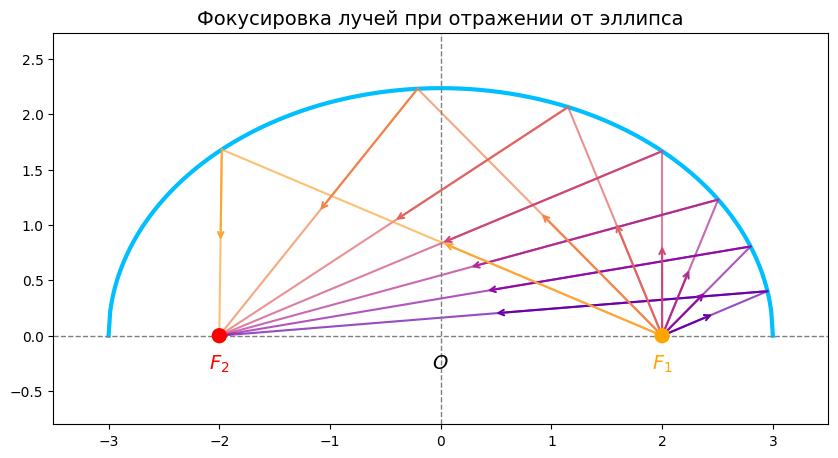

In [ ]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

x_sym = Symbol('x')
c_sym = Symbol('c')
y_sym = Function('y')(x_sym)
p = Symbol('p')  # dy/dx
C1 = Symbol('C_1')

# Векторы: F1(c, 0), F2(-c, 0), M(x, y), касательная tau(1, p)
r1 = Matrix([x_sym - c_sym, y_sym])
r2 = Matrix([-c_sym - x_sym, -y_sym])
tau = Matrix([1, p])

# Дифференциальное уравнение из закона отражения
ode_p = x_sym * y_sym * p**2 + (x_sym**2 - y_sym**2 - c_sym**2) * p - x_sym * y_sym
print("Дифференциальное уравнение отражающей кривой:")
display(Eq(ode_p, 0))
print()

# Переход к уравнению Клеро через замену u = x^2, v = y^2
u, v, dv_du = symbols('u v dv_du', positive=True)
ode_uv = ode_p.subs({p: sqrt(u/v)*dv_du, x_sym: sqrt(u), y_sym: sqrt(v)})
ode_uv = simplify(ode_uv * sqrt(v/u))

# Выбираем первый элемент из списка решений [0]
v_expr = solve(ode_uv, v)[0]

# Решение уравнения Клеро и каноническая форма
v_sol = v_expr.subs(dv_du, C1)
A = Symbol('A')
canonical_form = Eq(x_sym**2 / A + y_sym**2 / (A - c_sym**2), 1)

print("Каноническое решение (семейство эллипсов и гипербол):")
display(canonical_form)


# Параметры геометрии (выберем конкретный эллипс для графика)
c = 2.0      # Половина фокусного расстояния (фокусы в -2 и 2)
a = 3.0      # Большая полуось эллипса
b = np.sqrt(a**2 - c**2) # Малая полуось эллипса

# Точки фокусов
F1 = np.array([c, 0])
F2 = np.array([-c, 0])

# Настройка графика
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Генерация точек эллипса (верхняя дуга)
x_ell = np.linspace(-a, a, 400)
y_ell = b * np.sqrt(1 - (x_ell / a)**2)
ax.plot(x_ell, y_ell, label='Отражающая кривая (Эллипс)', color='deepskyblue', linewidth=3)

# Отмечаем фокусы (исправленный формат координат для scatter)
ax.scatter([F1[0], F2[0]], [F1[1], F2[1]], color=['orange', 'red'], s=100, zorder=5)
ax.text(c, -0.3, '$F_1$', fontsize=14, color='orange', ha='center')
ax.text(-c, -0.3, '$F_2$', fontsize=14, color='red', ha='center')
ax.text(0, -0.3, '$O$', fontsize=14, color='black', ha='center')

# Строим сетку падающих и отраженных лучей
angles = np.linspace(0.4, np.pi - 0.4, 7)
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(angles)))

for angle, color in zip(angles, colors):
    dx, dy = np.cos(angle), np.sin(angle)

    # Расчет точки пересечения луча из F1 с эллипсом
    A_quad = (dx / a)**2 + (dy / b)**2
    B_quad = 2 * c * dx / (a**2)
    C_quad = (c / a)**2 - 1

    roots = np.roots([A_quad, B_quad, C_quad])
    t = max(roots)

    # Координаты точки отражения M на эллипсе
    M = F1 + t * np.array([dx, dy])

    # Рисуем линии лучей
    ax.plot([F1[0], M[0]], [F1[1], M[1]], color=color, alpha=0.7, linewidth=1.5)
    ax.plot([M[0], F2[0]], [M[1], F2[1]], color=color, alpha=0.7, linewidth=1.5)

    # Добавляем стрелочки направления движения света
    ax.annotate('', xy=((F1[0]+M[0])/2, (F1[1]+M[1])/2), xytext=(F1[0], F1[1]),
                 arrowprops=dict(arrowstyle="->", color=color, lw=1.5))
    ax.annotate('', xy=((M[0]+F2[0])/2, (M[1]+F2[1])/2), xytext=(M[0], M[1]),
                 arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

# Оформление осей координат
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.xlim_val = (-a - 0.5, a + 0.5)
ax.ylim_val = (-0.8, b + 0.5)
ax.set_xlim(ax.xlim_val)
ax.set_ylim(ax.ylim_val)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Фокусировка лучей при отражении от эллипса', fontsize=14)
plt.show()
